In [1]:
import joblib
import os
import matplotlib.pyplot as plt
import numpy as np
import config

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, precision_score, recall_score
)

In [2]:
# Path to your saved artifacts
output_dir = "lasso_grid_search"

# Load everything
best_model = joblib.load(os.path.join(output_dir, "lasso_model.joblib"))
grid_search = joblib.load(os.path.join(output_dir, "lasso_gridsearch.joblib"))
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))

print("All artifacts loaded successfully!")
print("Best parameters:", grid_search.best_params_)


c:\Users\gench\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gench\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator VarianceThreshold from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gench\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle e

All artifacts loaded successfully!
Best parameters: {'clf__C': 1}


In [3]:
cv_results = grid_search.cv_results_

mean_test_scores = cv_results['mean_test_score']
std_test_scores = cv_results['std_test_score']
params = cv_results['params']

print("Grid Search Results:\n")
for mean, std, param in zip(mean_test_scores, std_test_scores, params):
    print(f"Parameters: {param}")
    print(f"Mean AUC-ROC: {mean:.4f} ± {std:.4f}")
    print("-" * 40)


Grid Search Results:

Parameters: {'clf__C': 0.1}
Mean AUC-ROC: 0.5569 ± 0.0548
----------------------------------------
Parameters: {'clf__C': 1}
Mean AUC-ROC: 0.5733 ± 0.0508
----------------------------------------
Parameters: {'clf__C': 10}
Mean AUC-ROC: 0.5650 ± 0.0545
----------------------------------------


Evaluating on Training Data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
True Positives (TP): 49
False Positives (FP): 43
True Negatives (TN): 215
False Negatives (FN): 9
Precision: 0.533
Recall: 0.845
AUC-ROC: 0.9303


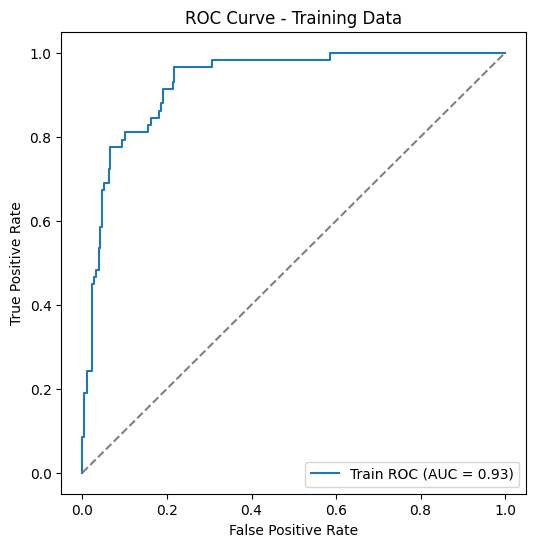

In [4]:
print("Evaluating on Training Data")

y_train_pred = best_model.predict(X_train)
if hasattr(best_model, "predict_proba"):
    y_scores_train = best_model.predict_proba(X_train)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_train = best_model.decision_function(X_train)
else:
    y_scores_train = y_train_pred

cm_train = confusion_matrix(y_train, y_train_pred)
tn, fp, fn, tp = cm_train.ravel()

precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
roc_auc = roc_auc_score(y_train, y_scores_train)

print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_train, y_scores_train)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Train ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Data")
plt.legend()
plt.show()


Evaluating on Validation Data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
True Positives (TP): 7
False Positives (FP): 11
True Negatives (TN): 44
False Negatives (FN): 6
Precision: 0.389
Recall: 0.538
AUC-ROC: 0.6895


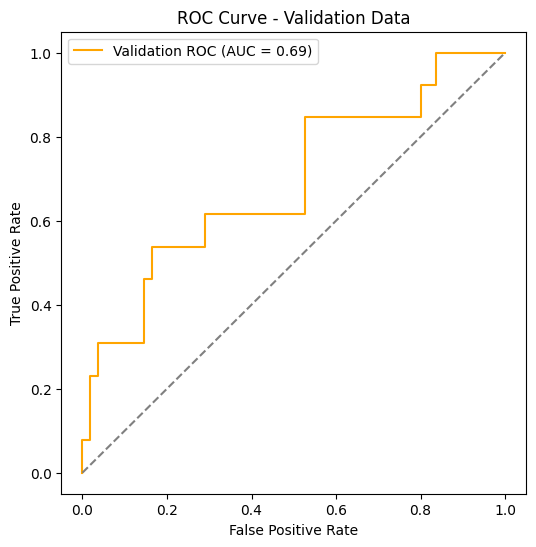

In [5]:
print("Evaluating on Validation Data")

y_val_pred = best_model.predict(X_val)
if hasattr(best_model, "predict_proba"):
    y_scores_val = best_model.predict_proba(X_val)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_val = best_model.decision_function(X_val)
else:
    y_scores_val = y_val_pred

cm_val = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm_val.ravel()

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_scores_val)

print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_scores_val)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Validation ROC (AUC = {roc_auc:.2f})", color="orange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Data")
plt.legend()
plt.show()


Evaluating on Test Data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
AUC-ROC (Test): 0.6890


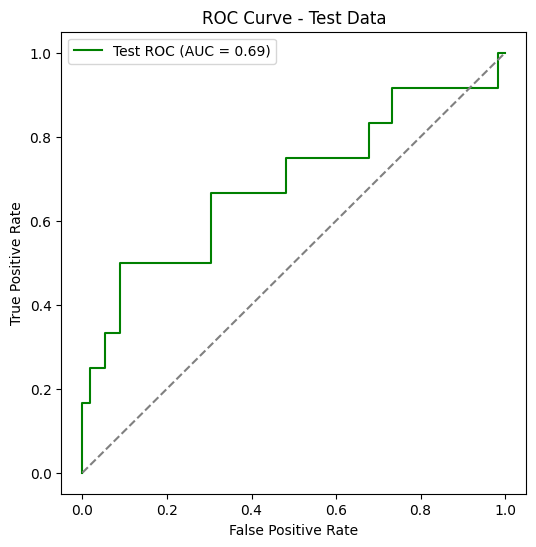

In [6]:
print("Evaluating on Test Data")

y_test_pred = best_model.predict(X_test)
if hasattr(best_model, "predict_proba"):
    y_scores_test = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_test = best_model.decision_function(X_test)
else:
    y_scores_test = y_test_pred

roc_auc_test = roc_auc_score(y_test, y_scores_test)
print(f"AUC-ROC (Test): {roc_auc_test:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_scores_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Test ROC (AUC = {roc_auc_test:.2f})", color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.show()